## Building a random walk in SigAlg

First, we recall that a *stochastic process* (or simply, a *process*), with index set $T \subset \mathbb{R}$, is a function

$$
X: T \times \Omega \to \mathbb{R},
$$

where $\Omega$ is a probability space and each function

$$
X_t \stackrel{\text{def}}{=} X(t,-): \Omega \to \mathbb{R}, \quad \omega \mapsto X(t,\omega),
$$

for all $t\in T$, is a random variable on $\Omega$ (i.e., a measurable function). Thus, a stochastic process can be viewed as a collection of random variables indexed by the set $T$.

The set $T$ is often referred to as *time*, and when $T$ is countable we say that $X$ is a *discrete-time* stochastic process, while when $T$ is an interval in $\mathbb{R}$ we say that $X$ is a *continuous-time* stochastic process. Similarly, if each random variable $X_t$ is discrete, we say that $X$ is a *discrete-state* stochastic process, while if each $X_t$ is continuous, we say that $X$ is a *continuous-state* stochastic process.

By holding a sample point $\omega\in \Omega$ fixed and letting $t$ vary over the index set $T$, we obtain a real-valued function

$$
X(\omega) \stackrel{\text{def}}{=} X(-, \omega): T\to \mathbb{R}, \quad t\mapsto X(t,\omega) \in \mathbb{R}
$$

which is called a *trajectory* (or *sample path*) of the stochastic process $X$. Thus, a stochastic process can also be thought of as a collection of trajectories indexed by the sample space $\Omega$.

Perhaps the simplest example of a stochastic process is an *independent and identically distributed* (IID) process, where each random variable $X_t$ is independent from all other random variables $X_s$ for $s \neq t$, and all random variables $X_t$ have the same probability distribution. A simple example of an IID process is a sequence of Bernoulli random variables indexed by a finite set $T = \{1,2,\ldots,n\}$, which can be used to model a sequence of $n$ coin flips where $X_t = 1$ represents heads and $X_t = 0$ represents tails on the $t$-th flip. Such a process can be implemented using the SigAlg library and its interface with SciPy:

In [1]:
import sigalg as sa
from scipy.stats import bernoulli

T = sa.Time.discrete(length=2)

X = sa.IIDProcess.generate(
    distribution=bernoulli(p=0.7), support=[0, 1], mode="enum", index=T
)
print(X)

IID process 'X':
t      0  1  2
omega         
0      0  0  0
1      0  0  1
2      0  1  0
3      0  1  1
4      1  0  0
5      1  0  1
6      1  1  0
7      1  1  1


The printout shows an IID process $X$ on the index set $T = \{0,1,2\}$, where each $X_t$ is a Bernoulli random variable with parameter $p=0.7$. Since each $X_t$ has only two possible outcomes, the entire process has $2^3 = 8$ possible trajectories, all being listed in the printout.

Each trajectory $X(\omega)$ of the process has a probability, computed as the product of the probabilities of each individual random variable along the trajectory:

$$
P(X(\omega)) = \prod_{t=0}^2 P(X_t = X(t,\omega)).
$$

(This uses the independence of the random variables $X_t$ in the IID process.) For example, for the trajectory $\omega_3$ (corresponding to trajectory `3` in the printout above) we have

$$
P(X(\omega_3)) = P(X_0 = 0) P(X_1 = 1) P(X_2 = 1) = 0.3 \cdot 0.7^2 = 0.147.
$$

The probabilities of each trajectory can be accessed via the `probability_measure` attribute of the process:

In [2]:
P_X = X.measure.with_name("P_X")
print(P_X)

Probability measure 'P_X':
         P_X
omega       
0      0.027
1      0.063
2      0.063
3      0.147
4      0.063
5      0.147
6      0.147
7      0.343


Longer trajectories can be generated by increasing the `length` parameter in the `Time` instance, though care must be taken since the number of possible trajectories grows exponentially with the length of the process. For long processes, it is often more practical to work with simulations or samples of trajectories rather than enumerating all possible trajectories. In the next code block, we simulate a single trajectory of length 100 from the same IID Bernoulli process above and plot it:

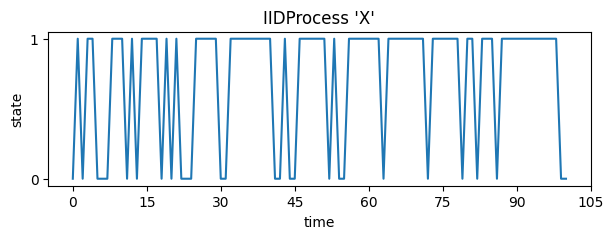

In [3]:
import matplotlib.pyplot as plt

T = sa.Time.discrete(length=100)
X.time = T

X.n_trajectories = 1
X.random_state = 42
X.mode = "sim"
X.regenerate()

_, ax = plt.subplots(figsize=(7, 2))
X.plot_trajectories(ax=ax)
plt.show()

Of course, the trajectory is actually a collection of points at either $0$ or $1$ along the vertical axis, but the plot connects these points with lines for visual clarity.

Now, let $n$ be a positive integer, $a$ a real number, and $p$ a real number in the interval $[0,1]$. A *random walk of length $n$, beginning at $a$,* is a stochastic process $X$ indexed by $T = \{1,2,\ldots,n\}$ with the following properties:

1. The increments
    $$
    \Delta X_t \stackrel{\text{def}}{=} X_t - X_{t-1}, \quad t = 1,2,\ldots,n,
    $$
    are IID random variables. (We set $X_0=a$.)
2. Each increment $\Delta X_t$ takes either the value $1$ or $-1$, the former with probability $p$ and the latter with probability $1-p$.

Technically, this is a random walk *with drift*, since the expected value of each increment is $E(\Delta X_t) = 2p - 1$, which is nonzero when $p \neq 0.5$. When $p = 0.5$, the random walk is said to be *symmetric*, since the expected value of each increment is zero.

The reason for the name "random walk" is that each trajectory $X(\omega)$ can be visualized as a path on the integer number line starting at the point $a$, where at each discrete time a step is taken that moves either one unit to the right (with probability $p$) or one unit to the left (with probability $1-p$). Over many steps, this results in a "wandering" behavior that resembles a random walk. The random variable $X_t$ represents the position of the walk after $t$ steps.

The SigAlg library provides the `RandomWalk` class to model these processes, but it is instructive to build a random walk from scratch using the above recipe. To do this, note that each $X_t$ is the cumulative sum of the increments up to time $t$, plus the initial state $X_0 = a$:

$$
X_t = X_0 + \sum_{s=1}^t \Delta X_s.
$$
[Notice the formal similarity between this equation and the the Fundamental Theorem of Calculus: $$f(t) = f(0) + \int_0^tdf(s),$$ where we write $df(s) = f'(s) \, ds$.]{.aside}

Thus, if we can model the increments $\Delta X_t$ as an IID process, we can then define the random walk $X$ as the cumulative sum of these increments plus the starting point $a$. But, for each $t$, we clearly have

$$
\Delta X_t = 2B_t -1,
$$

where $B_t$ is a Bernoulli random variable with parameter $p$. Therefore, with $n=10$, $a=0$, and $p=0.7$, we can build a random walk process as follows, and then simulate 10 trajectories from it:

In [4]:
T = sa.Time.discrete(start=1, stop=10)

B = sa.IIDProcess.generate(
    distribution=bernoulli(p=0.7),
    support=[0, 1],
    mode="sim",
    n_trajectories=10,
    index=T,
    name="B",
    random_state=42,
)
# Construct the increment process
Delta_X = 2 * B - 1

# Add the initial state
Delta_X = Delta_X.insert_rv(time=0, state=0)

# Construct the random walk process by cumulative summation
X = Delta_X.cumsum(name="X")

print(X)

Stochastic process 'X':
t      0   1   2   3   4   5   6   7   8   9   10
omega                                            
0       0  -1   0  -1   0   1   0  -1  -2  -1   0
1       0   1   0   1   0   1   2   3   4   3   4
2       0  -1   0  -1  -2  -3  -2  -1   0   1   2
3       0  -1  -2  -1   0   1   2   3   4   5   6
4       0   1   0  -1   0  -1  -2  -1   0   1   2
5       0   1   2   1   2   1   0   1   2   3   4
6       0   1   2   3   2   3   4   5   6   7   8
7       0   1   2   1   2   3   4   5   6   7   6
8       0   1   2   1   2   3   4   3   4   5   6
9       0   1   2   3   4   5   6   7   8   9   8


So, for example, we see that the final position of trajectory `3` is `6`. A plot of these simulated trajectories is shown below:

In [ ]:
_, ax = plt.subplots(figsize=(7, 3))
X.plot_trajectories(ax=ax, plot_kwargs={"alpha": 0.7})
plt.show()

Longer trajectories reveal the "drift" that we mentioned above. To make these longer trajectories, we use the built-in `RandomWalk` class in SigAlg, which internally implements the same construction as above. The following code simulates 10 trajectories of length 100 from a random walk with $p=0.7$ and plots them:

In [ ]:
T = sa.Time.discrete(length=100)
X = sa.RandomWalk(p=0.7, time=T).from_simulation(
    n_trajectories=10,
    random_state=42,
)

_, ax = plt.subplots(figsize=(7, 4))
X.plot_trajectories(ax=ax, plot_kwargs={"alpha": 0.7})
plt.show()


While random, it is evident that the trajectories tend to drift upwards over time, since the expected increment is positive: $E(\Delta X_t) = 2 \cdot 0.7 - 1 = 0.4 > 0$.

## Time-evolution of transition probabilities: diffusion

Imagine that, at time $0$, you attempt to predict the future value $X_t$ of a random walk at some future time $t$. From the plots of the trajectories immediately above, it is evident that your prediction will *always* be uncertain, and that this uncertainty grows larger as $t$ increases. The probability distribution that describes this uncertainty is exactly the law of the random variable $X_t$, which we might write as

$$
P(X_t = x \mid X_0 = a)
$$

to emphasize that the random walk starts at $X_0 = a$. When written like this, the law is understood as a *transition probability distribution*, since it gives the probabilities of transitioning from the state $X_0 = a$ at time $0$ to the various possible states $X_t=x$ at time $t$. The fact that this probability distribution "spreads out" as $t$ increases is known as *diffusion*, and it is a fundamental property of random walks and many other stochastic processes.

In fact, if the random walk has probability parameter $p$, then we have

$$
V(\Delta X_t) = V(2B_t - 1) = 4pq,
$$ 

where we set $q=1-p$, and where $B$ is the IID Bernoulli process used to construct the increments in the previous section. Since the increments are independent, it then follows that

$$
V(X_t) = \sum_{s=1}^t V(\Delta X_s) = 4tpq.
$$ {#eq-variance-random-walk}

Thus, the variances of a random walk grow linearly as a function of time $t$. As for the expectations, we have
$$
E(X_t) = X_0 + \sum_{s=1}^t E(\Delta X_s) = X_0 + t(p-q),
$$ {#eq-expectation-random-walk}

so the expectations also grow linearly as a function of time $t$.

These observations, along with the plots in the previous section, suggest that the time-evolution of the law of $X_t$ consists of a "peak" that moves linearly with time (according to the expectation) while simultaneously diffusing (according to the variance).

This evolution may be observed experimentally in SigAlg, as shown in the following plot. We simulate 10,000 trajectories of a random walk with $p=0.7$ and then plots histograms of the values of $X_t$ for various $t$ in a "ridgeline" plot:

```{python}
# | fig-align: center
# | code-fold: true

from matplotlib.colors import LinearSegmentedColormap

blue = "#3399FF"
purple = "#AA77CC"

T = Time.discrete(length=200)

X = RandomWalk(
    p=0.7,
    name="X",
    time=T,
).from_simulation(
    n_trajectories=10_000,
    random_state=42,
)

_, ax = plt.subplots(figsize=(7, 5))

n_plots = 8
time_step = 25  # 200 = 8 * 25

times = [time_step * k for k in range(1, n_plots + 1)]
cmap = LinearSegmentedColormap.from_list("conditional_cmap", [yellow, purple, blue])
colors = [cmap(i / (n_plots - 1)) for i in range(n_plots)]

for color, t in zip(colors, times):
    probabilities = X[t - 1].range.probability_measure.data
    probabilities.index = X[t - 1].range.data.values

    ax.bar(
        x=probabilities.index,
        height=-probabilities.values * 175,
        width=0.8,
        color=color,
        bottom=t,
    )

ax.invert_yaxis()
ax.set_xlabel("state")
ax.set_ylabel("time")
ax.set_title(
    "Time-evolution of the probability distribution\nof a random walk",
)
plt.tight_layout()
plt.show()

```

As we expected, the peak of the distribution drifts toward higher values as time increases, while simultaneously diffusing.

It is not difficult to write down a formula for the last of $X_t$; in fact, we accomplish this in [@thm-explicit-discrete-law]. However, it is also possible to describe the time-evolution of the law of $X_t$ using a special *difference equation*, which is the discrete starting point for the Fokker-Planck partial differential equation that we will study later.

::: {#thm-discrete-diffusion-equation}
## Discrete Diffusion Equation

Let $X$ be a random walk with probability parameter $p$, starting at position $a$, and write $q=1-p$. If we write

$$
f(x,t) = P(X_t = x)
$$

for the probability function of $X_t$, then for all integers $t \geq 0$ and all $x \in \mathbb{Z}$, we have
$$
f(x,t+1) - f(x,t) = p \big( f(x-1,t) - f(x,t) \big) + q \big( f(x+1,t) - f(x,t) \big),
$$

along with the initial conditions
$$
f(a, 0) = 1, \quad f(x,0) = 0 \text{ for } x \neq a.
$$
:::

::: {.callout-note collapse="true" icon="false"}
## Proof.
From the law of total probability, we have

$$
P(X_{t+1}=x) = \sum_{y\in \mathbb{Z}} P(X_{t+1}=x \mid X_t = y) P(X_t = y).
$$

However, the conditional probabilities on the right-hand vanish except when $y = x-1$ or $y = x+1$, since the random walk can only move one unit to the left or right at each time step. Thus, we have

$$
f(x,t+1) = p f(x-1,t) + q f(x+1,t).
$$

Then, if we subtract $f(x,t)$ from both sides and use that $p+q=1$, we get

$$
f(x,t+1) - f(x,t) = p \big( f(x-1,t) - f(x,t) \big) + q \big( f(x+1,t) - f(x,t) \big),
$$

as claimed.
:::

Thus, the (forward) time increment of the probability function $f(x,t)$ is given by a weighted sum of the spatial increments to the left and right, with weights given by the probabilities $p$ and $q$. We will see this same sort of structure in the Fokker-Planck equation, where a time derivative is equal to an expression involving spatial derivatives.




::: {#thm-explicit-discrete-law}
## Law of Random Walk
Let $X$ be a random walk with probability parameter $p$, starting position $a$, and write $q=1-p$. Then the probability function $f(x,t)$ of $X_t$ is given by the formula

$$
f(x,t) = \binom{t}{\frac{x-a+t}{2}} p^{\frac{x-a+t}{2}} q^{\frac{t-x+a}{2}},
$$

for all integers $t\geq 0$ and all

$$
x \in \{ a-t, a-t+2, a-t+4, \ldots, a+t \}.
$$
:::

::: {.callout-note collapse="true" icon="false"}
## Proof.

For each integer $t\geq 1$, we have that

$$
X_t = a + \sum_{s=1}^t \Delta X_s = a + \sum_{s=1}^t (2B_s - 1) = a-t + 2Y,
$$

where $Y$ is a binomial random variable with parameters $t$ and $p$. Then $X_t=x$ if and only if $Y = \frac{x - a + t}{2}$, so the result follows from the probability function of the binomial distribution.
:::

## Scaled random walks

We now construct a scaled random walk. First, we fix a position $x\in \bbr$ and a time $t>0$. We then have a spatial interval from the starting position $a$ to the position $x$, of length $|x - a|$, and also a time interval from $0$ to $t$, of length $t$. We chop these intervals into $m$ and $n$ subintervals of equal lengths

$$
h = \frac{|x - a|}{m} \quad \text{and} \quad \tau = \frac{t}{n},
$$ {#eq-step-sizes}

respectively. Note that as $m,n\to \infty$, the step sizes $h$ and $\tau$ both shrink to zero. The goal is to understand what happens to as these step sizes vanish.

For each integer $k=1,2,\ldots,n$, we define the increments

$$
\Delta X_{k\tau}^{(h,\tau)} = h(2B_k - 1),
$$

so that each increment is a random variable that takes the value $h$ with probability $p$ and the value $-h$ with probability $1-p$. Then, we define

$$
X_t^{(h,\tau)} = a + \sum_{k=1}^n \Delta X_{k\tau}^{(h,\tau)}
$$

and compute

$$
E\big(X_t^{(h,\tau)}\big) = a + t\cdot   \frac{h}{\tau} (p - q),
$$

and

$$
V\big(X_t^{(h,\tau)}\big) = t\cdot 4\frac{h^2}{\tau} p q.
$$

Now, let the step sizes $h$ and $\tau$ go to $0$. From these formulas, it is clear that we need to do this in a controlled way, otherwise the expectations and variances will either blow up to infinity or vanish. In particular, if $h^2$ goes to zero faster than $\tau$, then the variance will shrink to zero, and the random variable $X_t^{(h,\tau)}$ will be deterministic in the limit. Conversely, if $\tau$ goes to zero faster than $h^2$, then the variance will blow up to infinity, and the random walk will become wildly erratic in the limit. To avoid these extremes, we impose a *scaling condition* that $h^2$ and $\tau$ go to zero at the same rate; that is, we require that there exists a positive constant $D>0$ such that

$$
\frac{h^2}{\tau} = D
$$

as $h,\tau \to 0$. This constant (which has units of squared length over time) is known as a *diffusion coefficient*.

However, note that this scaling condition creates a problem in the expectation. Indeed, unless $p=q=1/2$, the expectation will still blow up to either positive or negative infinity as $h,\tau \to 0$. To avoid this, we need to also impose a second condition that $p$ and $q$ depend on $h$ and $\tau$ in such a way that there is a constant $\mu \in \mathbb{R}$ such that

$$
D\cdot \frac{p-q}{h} = \mu
$$

as $h,\tau\to 0$. Note that this condition indeed implies that $p$ and $q$ both approach $1/2$ as $h,\tau \to 0$. This constant (which has units of length over time) is known as a *drift coefficient*.

Putting all this together, we find that under these scaling conditions, the expectations and variances of the scaled random walk converge to

$$
E(X_t^{(h,\tau)}) \to a + \mu t,
$$

and

$$
V(X_t^{(h,\tau)}) \to Dt.
$$

Now, is it actually possible to have $h$ and $\tau$ go to $0$ while satisfying these scaling conditions? Yes! For example, we can set $n=m^2$ and

$$
p = \frac{1}{2} + \frac{1}{2m},
$$

and then let $m\to \infty$.

```{python}
# | fig-align: center
# | code-fold: true

def gen_random_walk(m, x, t, n_trajectories, random_state=None):
    n = m**2  # number of time steps
    h = x / m  # size of space step
    tau = t / n  # size of time step
    p = 0.5 + 1 / (2 * m)  # probability of up move

    T = Time.continuous(start=tau, stop=t, num_points=n)

    B = IIDProcess(
        distribution=bernoulli(p=p),
        time=T,
        name="B",
    ).from_simulation(
        n_trajectories=n_trajectories,
        random_state=random_state,
    )

    # Construct the increment processes
    Delta_X = h * (2 * B - 1)

    # Add the initial state
    a = RandomVariable(domain=B.domain, name=0).from_constant(0)
    Delta_X.add_initial_state(a)

    # Construct the random walk processes by cumulative summation
    X = Delta_X.cumsum(name="X")

    return X


# Number of space steps
m1 = 10
m2 = 30

x = 30  # space endpoint
t = 10  # time endpoint

n_trajectories = 1

X1 = gen_random_walk(m1, x, t, n_trajectories, random_state=42).with_name("X1")
X2 = gen_random_walk(m2, x, t, n_trajectories, random_state=42).with_name("X2")

_, ax = plt.subplots(figsize=(6, 5))
X1.plot_trajectories(
    ax=ax,
    colors=[yellow],
    plot_kwargs={"linewidth": 1},
)
X2.plot_trajectories(
    ax=ax,
    colors=[blue],
    plot_kwargs={"linewidth": 1},
)
ax.set_title("Scaled random walks")
plt.show()
```


```{python}
# | fig-align: center
# | code-fold: true

n_trajectories = 50

X1 = gen_random_walk(m1, x, t, n_trajectories, random_state=42).with_name("X1")
X2 = gen_random_walk(m2, x, t, n_trajectories, random_state=42).with_name("X2")

_, ax = plt.subplots(figsize=(6, 5))
X1.plot_trajectories(
    ax=ax,
    colors=[yellow],
    plot_kwargs={"linewidth": 1, "alpha": 0.3},
)
X2.plot_trajectories(
    ax=ax,
    colors=[blue],
    plot_kwargs={"linewidth": 1, "alpha": 0.3},
)
ax.set_title("Scaled random walks")
plt.show()
```